# 01 · Prep — one function: read a unit, return the data the baseline walk needs

## Executive summary (read this first)

The baseline model is the **cumulative random walk with Cholesky**. This notebook defines **one function**,
`prepare_unit(unit_dir)`, that reads any card (F1 to F4) and returns everything the walk needs:

```python
d = prepare_unit("units/t2-F3-boj-ust-channel-2023")
d["card"], d["history"], d["freq"], d["steps"], d["horizon_steps"], d["targets"], d["summary"]
```

| key | what it is |
|---|---|
| `card` | assets and horizons in card order, target type (`level` / `log_return`), as-of, panel file of each asset |
| `history` | each asset's values up to the as-of, from its own panel file (nothing later is read) |
| `freq` | each asset's panel: `daily` or `monthly` |
| `steps` | one column per asset: change from the previous row (level) or log(1 + r) (log return) |
| `horizon_steps` | each horizon counted in rows of the asset's panel (daily: as is; monthly: months) |
| `targets` | the train / test table: one row per (origin date, asset, horizon) |
| `summary` | one line about the card: sizes, frequencies, number of train / test dates |

**The train / validation / test table.** For every past date ("origin") it writes down what the card would
have asked if that date had been the as-of: the value `k` rows later (level) or the sum of `log(1 + r)` over
the next `k` rows (log return), and the anchor the walk starts from. The split is **by time**:

```
train ──┤purged├── validation ──┤purged├── test ──…── as-of
```

The latest 30% of origins are `test` (kept hidden until the very end), the latest 30% of what is left is
`validation` (to choose between models), the rest is `train` (to fit and tune). Origins whose outcome would
fall inside the next block are dropped (`purged`), so no two blocks share an outcome. One `predict` row per
cell holds the real as-of.

The function is defined in §1, as a normal cell. §7 checks on all 103 cards that it gives exactly the
data the production walk uses. No realized outcome is read.

## 0 — Setup

In [1]:
import importlib, pathlib, sys
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

HERE = pathlib.Path.cwd() if pathlib.Path.cwd().name == "model_baseline" else pathlib.Path.cwd() / "model_baseline"
REPO, DATA, UNITS = HERE.parent, HERE / "data", HERE.parent / "units"
for p in (str(HERE), str(REPO)):
    if p not in sys.path: sys.path.insert(0, p)

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
SPLIT = {"train": "#2a78d6", "purged": "#c3c2b7", "validation": "#1baf7a", "test": "#eb6834"}
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "axes.axisbelow": True, "grid.color": GRID, "axes.edgecolor": INK2,
                     "axes.titlelocation": "left", "legend.frameon": False, "font.size": 10})
print("cards:", len(list(UNITS.glob("t2-F*"))))

cards: 103


## 1 — The function

Seven steps, in order.

In [2]:
import tomllib

MONTHLY_SPACING_DAYS = 20      # rows further apart than this (median) = a monthly panel


def prepare_unit(unit_dir, horizons=None, test_frac=0.3, val_frac=0.3, stride=1) -> dict:
    """Read one unit folder. Returns a dict: card, history, freq, steps, horizon_steps, targets, summary.

    horizons  -- ask for these horizons (business days, like the card) instead of the card's own
    test_frac -- share of origins, the latest ones, that are "test"
    val_frac  -- share of the origins before test, the latest ones, that are "validation"
    stride    -- keep every n-th origin only (a smaller table)
    """
    unit_dir = pathlib.Path(unit_dir)

    # 1. The card -------------------------------------------------------------------------------
    c = tomllib.loads((unit_dir / "card.toml").read_text())
    t = c["targets"]
    assets = [str(a) for a in t["asset_ids"]]                     # card order: every table uses it
    hz = sorted({int(h) for h in horizons}) if horizons is not None else [int(h) for h in t["horizons"]]
    target_type = t["target_type"]                                 # "level" or "log_return"
    log_return = target_type == "log_return"
    asof = pd.Timestamp(c["provenance"]["data_cutoff"])
    day = str(asof.date())

    # 2. History: each asset from the first panel file (by name) that holds it, rows on/before the as-of
    history, panel_of = {}, {}
    for f in sorted(unit_dir.glob("*.parquet")):
        p = pd.read_parquet(f)
        acol = next((col for col in ("asset", "asset_id") if col in p.columns), None)
        if acol is None:
            continue
        p = p.assign(_asset=p[acol].astype(str), _day=p["date"].astype(str).str[:10])
        for a in assets:
            rows = p[(p._asset == a) & (p._day <= day)].sort_values("_day")
            if a not in history and len(rows):
                history[a] = pd.Series(rows["value"].astype(float).to_numpy(),
                                       index=pd.DatetimeIndex(pd.to_datetime(rows["_day"].to_numpy())), name=a)
                panel_of[a] = f.stem
    missing = [a for a in assets if a not in history]
    if missing:
        raise ValueError(f"{c['task']['id']}: no panel file holds {missing} on or before {day}")
    history = {a: history[a] for a in assets}                      # card order
    panel_of = {a: panel_of[a] for a in assets}

    def hole(s):
        """True on a row whose gap from the previous row is a hole: > max(10 x the usual gap, 5 days)."""
        days = pd.Series(s.index, index=s.index).diff().dt.days
        if days.notna().sum() == 0:
            return pd.Series(False, index=s.index)
        return days > max(float(days.median()) * 10.0, 5.0)

    # 3. Steps: change from the previous row (level) or log(1 + r) (log return); none across a hole
    def asset_steps(s):
        if log_return:
            v = s.to_numpy(float)
            if np.any(v <= -1.0) or np.any(np.isinf(v)):
                raise ValueError(f"{s.name}: log_return history needs finite returns above -100%")
            return pd.Series(np.log1p(v), index=s.index, name=s.name)
        return s.diff().where(~hole(s))
    steps = pd.DataFrame({a: asset_steps(history[a]) for a in assets})[assets].dropna()   # dates every asset has

    # 4. Horizon steps: daily = the horizon as is; monthly = months from the last observation
    #    to the month of as-of + h business days (the official baseline's rule)
    freq, per_asset = {}, {}
    for a in assets:
        s = history[a]
        monthly = len(s) >= 3 and float(pd.Series(s.index).diff().dt.days.median()) > MONTHLY_SPACING_DAYS
        freq[a] = "monthly" if monthly else "daily"
        last, ks = s.index[-1], []
        for h in hz:
            if monthly:
                target = asof + pd.offsets.BDay(h)
                k = 12 * (target.year - last.year) + (target.month - last.month)
                ks.append(k if k > 0 else h)
            else:
                ks.append(h)
        per_asset[a] = ks
    horizon_steps = pd.DataFrame(per_asset, index=hz).T               # asset x horizon

    # 5. Targets for every row of every asset: k rows ahead, not across a hole
    parts = []
    for a in assets:
        s = history[a]
        n, v, idx = len(s), s.to_numpy(float), s.index
        holes_so_far = np.concatenate([[0], np.cumsum(hole(s).to_numpy())])     # holes in rows 0..j-1
        cum = np.concatenate([[0.0], np.cumsum(np.log1p(v))]) if log_return else None
        for h in hz:
            k = int(horizon_steps.loc[a, h])
            if n <= k:
                continue
            i = np.arange(n - k)                                       # origin rows with a row k ahead
            target = cum[i + k + 1] - cum[i + 1] if log_return else v[i + k]   # log(1+r) of rows i+1..i+k
            crosses = holes_so_far[i + k + 1] - holes_so_far[i + 1] > 0       # a hole in rows i+1..i+k
            keep = ~crosses & np.isfinite(target)
            parts.append(pd.DataFrame({"origin_date": idx[i][keep], "asset": a, "horizon": h, "steps": k,
                                       "target_date": idx[i + k][keep],
                                       "anchor": 0.0 if log_return else v[i][keep], "target": target[keep]}))
    df = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(
        columns=["origin_date", "asset", "horizon", "steps", "target_date", "anchor", "target"])

    # 6. Keep origins where every cell has a target. Split by time: the latest test_frac are "test";
    #    of the origins left, the latest val_frac are "validation"; the rest "train". An origin whose
    #    outcome reaches the next block is "purged", so no two blocks share an outcome.
    n_cells = len(assets) * len(hz)
    count = df.groupby("origin_date").size()
    origins = np.sort(count[count == n_cells].index.to_numpy())[::max(int(stride), 1)]
    df = df[df.origin_date.isin(origins)].copy()
    latest_outcome = df.groupby("origin_date").target_date.max()          # per origin: its last target date
    split = pd.Series("train", index=origins, dtype=object)

    def carve(frac, name):
        """The latest `frac` of the origins still 'train' become `name`; train origins reaching it are purged."""
        left = split.index[split == "train"]
        n = int(np.ceil(frac * len(left))) if len(left) else 0
        if n:
            first = left[-n]
            split[(split.index >= first) & (split == "train")] = name
            split[(split == "train") & (latest_outcome.reindex(split.index) >= first)] = "purged"

    carve(test_frac, "test")
    carve(val_frac, "validation")
    df["split"] = df.origin_date.map(split)

    # 7. The real forecast: one row per cell at the as-of (anchor and steps, no target)
    predict = pd.DataFrame([{"origin_date": history[a].index[-1], "asset": a, "horizon": h,
                             "steps": int(horizon_steps.loc[a, h]), "target_date": asof + pd.offsets.BDay(h),
                             "anchor": 0.0 if log_return else float(history[a].iloc[-1]),
                             "target": np.nan, "split": "predict"} for a in assets for h in hz])
    order = {a: j for j, a in enumerate(assets)}
    targets = (pd.concat([df, predict], ignore_index=True)
                 .assign(unit=c["task"]["id"], _a=lambda x: x.asset.map(order))
                 .sort_values(["split", "origin_date", "_a", "horizon"])
                 [["unit", "split", "origin_date", "asset", "horizon", "steps", "target_date", "anchor", "target"]]
                 .reset_index(drop=True))

    card = {"unit": c["task"]["id"], "family": c["metadata"]["category"], "assets": assets, "horizons": hz,
            "target_type": target_type, "value_unit": t.get("value_unit", ""), "asof": asof,
            "panel_of": panel_of, "unit_dir": unit_dir}
    scored = targets[targets.split != "predict"]
    summary = {"unit": card["unit"], "family": card["family"], "target_type": target_type, "assets": len(assets),
               "horizons": hz, "panels": sorted(set(panel_of.values())), "freq": sorted(set(freq.values())),
               "history_rows": min(len(s) for s in history.values()), "step_rows": len(steps),
               "horizon_steps": horizon_steps.iloc[0].tolist(),
               **{f"{x}_origins": int(scored.loc[scored.split == x, "origin_date"].nunique())
                  for x in ("train", "purged", "validation", "test")},
               "first_origin": scored.origin_date.min(),
               "first_validation": scored.loc[scored.split == "validation", "origin_date"].min(),
               "first_test": scored.loc[scored.split == "test", "origin_date"].min(),
               "asof": asof}
    return {"card": card, "history": history, "freq": freq, "steps": steps,
            "horizon_steps": horizon_steps, "targets": targets, "summary": summary}

## 2 — One card end to end: two assets, two horizons, two panel files

`t2-F3-boj-ust-channel-2023` asks for the US 10-year yield and USD/JPY. They live in different panel files
(`rates_daily` and `g10_fx_daily`), with different holiday calendars.

In [3]:
d = prepare_unit(UNITS / "t2-F3-boj-ust-channel-2023")
c = d["card"]
print(pd.Series({**{k: v for k, v in c.items() if k != "unit_dir"}, "freq": d["freq"]}).to_string())

unit                                  t2-F3-boj-ust-channel-2023
family                                                     T2-F3
assets                                            [UST_10Y, JPY]
horizons                                                [21, 63]
target_type                                                level
value_unit              percent_per_annum (UST_10Y); JPY-per-USD
asof                                         2023-07-21 00:00:00
panel_of       {'UST_10Y': 'rates_daily', 'JPY': 'g10_fx_daily'}
freq                        {'UST_10Y': 'daily', 'JPY': 'daily'}


**History** — each asset from its own panel, up to the as-of. The two calendars differ, so some dates exist for one asset only:

In [4]:
hist = pd.DataFrame(d["history"])
display(hist.tail(6))
print("rows: " + ", ".join(f"{a} {len(s):,}" for a, s in d["history"].items()) + f";  dates both have: {hist.dropna().shape[0]:,}")

,UST_10Y,JPY
2023-07-14,3.83,138.74
2023-07-17,3.81,138.92
2023-07-18,3.80,138.94
2023-07-19,3.75,139.76
2023-07-20,3.85,140.39
2023-07-21,3.84,141.75


rows: UST_10Y 5,892, JPY 5,907;  dates both have: 5,881


**Steps** and **horizon steps** — the walk measures its sd and correlation on the last 260 rows of `steps`:

In [5]:
display(d["steps"].tail(4))
last = d["steps"].iloc[-260:]
print("last 260 steps: sd", last.std(ddof=0).round(4).to_dict(), "  correlation", round(float(last.corr().iloc[0, 1]), 3))
d["horizon_steps"]

,UST_10Y,JPY
2023-07-18,-0.01,0.02
2023-07-19,-0.05,0.82
2023-07-20,0.10,0.63
2023-07-21,-0.01,1.36


last 260 steps: sd {'UST_10Y': 0.078, 'JPY': 1.1311}   correlation 0.416


,21,63
UST_10Y,21,63
JPY,21,63


**The train / test table** — first rows of each split, and the `predict` rows:

In [6]:
t = d["targets"]
display(pd.concat([t[t.split == s].head(4) for s in ("train", "purged", "validation", "test", "predict")]))
display(t.groupby("split").agg(rows=("target", "size"), origins=("origin_date", "nunique"),
                               first=("origin_date", "min"), last=("origin_date", "max")))

,unit,split,origin_date,asset,horizon,steps,target_date,anchor,target
7492,t2-F3-boj-ust-channel-2023,train,2000-01-03,UST_10Y,21,21,2000-02-02,6.58,6.60
7493,t2-F3-boj-ust-channel-2023,train,2000-01-03,UST_10Y,63,63,2000-04-03,6.58,6.00
7494,t2-F3-boj-ust-channel-2023,train,2000-01-03,JPY,21,21,2000-02-02,101.70,108.40
7495,t2-F3-boj-ust-channel-2023,train,2000-01-03,JPY,63,63,2000-04-03,101.70,104.82
4,t2-F3-boj-ust-channel-2023,purged,2010-12-20,UST_10Y,21,21,2011-01-20,3.36,3.47
5,t2-F3-boj-ust-channel-2023,purged,2010-12-20,UST_10Y,63,63,2011-03-22,3.36,3.34
6,t2-F3-boj-ust-channel-2023,purged,2010-12-20,JPY,21,21,2011-01-21,83.72,82.63
7,t2-F3-boj-ust-channel-2023,purged,2010-12-20,JPY,63,63,2011-03-23,83.72,80.94
18464,t2-F3-boj-ust-channel-2023,validation,2011-03-23,UST_10Y,21,21,2011-04-21,3.36,3.42
18465,t2-F3-boj-ust-channel-2023,validation,2011-03-23,UST_10Y,63,63,2011-06-22,3.36,3.01


,rows,origins,first,last
split,,,,
predict,4,1,2023-07-21,2023-07-21
purged,504,126,2010-12-20,2016-04-14
test,6984,1746,2016-04-15,2023-04-20
train,10972,2743,2000-01-03,2010-12-17
validation,4812,1203,2011-03-23,2016-01-13


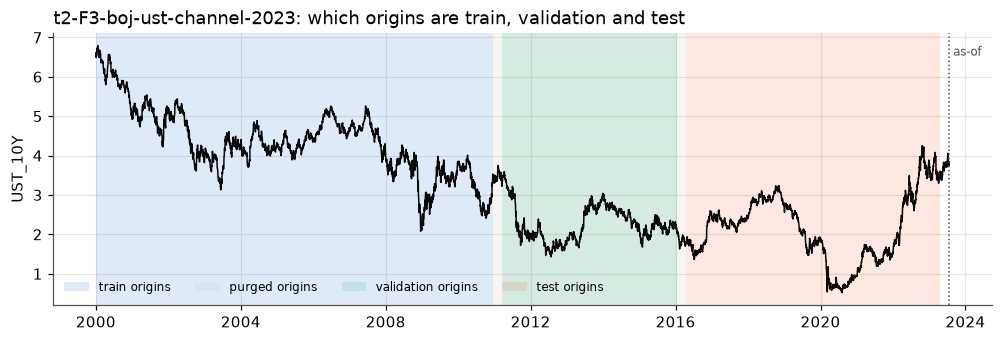

In [7]:
fig, ax = plt.subplots(figsize=(9, 3), layout="constrained")
s = d["history"][c["assets"][0]]
ax.plot(s.index, s.to_numpy(), color=INK, lw=1)
for split, col in SPLIT.items():
    o = t.loc[t.split == split, "origin_date"]
    if len(o): ax.axvspan(o.min(), o.max(), color=col, alpha=.15, lw=0, label=f"{split} origins")
ax.axvline(c["asof"], color=INK2, ls=":", lw=1); ax.text(c["asof"], s.max(), " as-of", fontsize=8, color=INK2, va="top")
ax.set_ylabel(c["assets"][0]); ax.legend(loc="lower left", ncols=4, fontsize=8)
ax.set_title(f"{c['unit']}: which origins are train, validation and test")
plt.show()

## 3 — A log-return card

`t2-F4-short-vol-2018`: the equity market factor `MKT`, cumulative log return over 21 business days. The
panel holds **daily returns r**, not prices. So a step is `log(1 + r)`, the target is the **sum** of the next
21 of them, and the anchor is 0. Checked against the repo's own definition
(`qfbench2_track_forecasting.targets.log_return_steps`):

In [8]:
from qfbench2_track_forecasting.targets import log_return_steps
d2 = prepare_unit(UNITS / "t2-F4-short-vol-2018"); t2 = d2["targets"]
r = d2["history"]["MKT"]
row = t2[t2.split == "train"].iloc[500]
i = r.index.get_loc(row.origin_date); k = int(row.steps)
direct = float(log_return_steps(r.iloc[i + 1: i + 1 + k].to_numpy()).sum())
print(f"horizon {d2['card']['horizons']} -> {k} steps.  origin {row.origin_date.date()}: table target {row.target:+.6f}, "
      f"sum of log(1+r) over the next {k} rows {direct:+.6f}, anchor {row.anchor}")
t2[t2.split == "predict"]

horizon [21] -> 21 steps.  origin 2002-01-02: table target -0.025939, sum of log(1+r) over the next 21 rows -0.025939, anchor 0.0


,unit,split,origin_date,asset,horizon,steps,target_date,anchor,target
0,t2-F4-short-vol-2018,predict,2018-01-26,MKT,21,21,2018-02-26,0.0,NaN


## 4 — A monthly card

`t2-F4-covid-nfp-2020`: US payrolls on a **monthly** panel, horizon 21 business days. One row is one month, so
the horizon is counted in months from the last observation (the as-of lags it by the publication delay):
**2**, the same as the official baseline's table (docs/M0-BASELINE.md §3.7).

In [9]:
d3 = prepare_unit(UNITS / "t2-F4-covid-nfp-2020"); c3 = d3["card"]; s3 = d3["history"]["NFP"]
print(f"freq {d3['freq']}; last observation {s3.index[-1].date()}, as-of {c3['asof'].date()}, "
      f"as-of + 21 BD = {(c3['asof'] + pd.offsets.BDay(21)).date()}")
d3["horizon_steps"]

freq {'NFP': 'monthly'}; last observation 2020-02-01, as-of 2020-03-31, as-of + 21 BD = 2020-04-29


,21
NFP,2


## 5 — A transfer card: a hole in the data

`t2-F2-cnh-stress-2015`: the target (`CNY`) ships as an **early window** plus **one row at the as-of**, with
the years between left out on purpose. A step across that hole would read as one day with a decade's move,
so it is dropped, and **no target crosses the hole**: every origin sits in the early window.

In [10]:
d4 = prepare_unit(UNITS / "t2-F2-cnh-stress-2015"); s4 = d4["history"]["CNY"]; t4 = d4["targets"]
gap = pd.Series(s4.index).diff().dt.days
j = int(gap.idxmax())
print(f"CNY: {len(s4):,} rows, {s4.index[0].date()} -> {s4.index[-1].date()}; biggest gap {s4.index[j-1].date()} -> {s4.index[j].date()} ({int(gap[j]):,} days)")
tt = t4[t4.split != "predict"]
print(f"origins {tt.origin_date.min().date()} -> {tt.origin_date.max().date()};  latest target date {tt.target_date.max().date()}")
print("steps kept across the hole:", int((d4["steps"].index == s4.index[j]).sum()))

CNY: 2,516 rows, 1995-07-31 -> 2015-07-31; biggest gap 2005-07-29 -> 2015-07-31 (3,654 days)
origins 1995-07-31 -> 2005-04-28;  latest target date 2005-07-29
steps kept across the hole: 0


## 6 — All 103 cards

In [11]:
prepared, errors = {}, []
for ud in sorted(UNITS.glob("t2-F*")):
    try:
        prepared[ud.name] = prepare_unit(ud)
    except Exception as exc:
        errors.append((ud.name, f"{type(exc).__name__}: {exc}"))
summary = pd.DataFrame([p["summary"] for p in prepared.values()]).set_index("unit")
print(f"prepared {len(prepared)} cards, {len(errors)} errors {errors or ''}")
display(summary.groupby("family").agg(
    cards=("family", "size"), level=("target_type", lambda x: (x == "level").sum()),
    log_return=("target_type", lambda x: (x == "log_return").sum()),
    monthly=("freq", lambda x: sum("monthly" in f for f in x)), two_panels=("panels", lambda x: sum(len(p) > 1 for p in x)),
    max_assets=("assets", "max"), min_train=("train_origins", "min"), min_validation=("validation_origins", "min"),
    min_test=("test_origins", "min")))
summary

prepared 103 cards, 0 errors 


,cards,level,log_return,monthly,two_panels,max_assets,min_train,min_validation,min_test
family,,,,,,,,,
T2-F1,23,21,2,2,0,2,28,55,82
T2-F2,27,27,0,0,0,2,361,182,287
T2-F3,22,19,3,0,5,10,352,205,348
T2-F4,31,20,11,2,0,3,114,50,72


,family,target_type,assets,horizons,panels,freq,history_rows,step_rows,horizon_steps,train_origins,purged_origins,validation_origins,test_origins,first_origin,first_validation,first_test,asof
unit,,,,,,,,,,,,,,,,,
t2-F1-ai-mom-2024,T2-F1,log_return,1,[127],[factors_daily],[daily],6142,6142,[127],2731,254,1225,1805,2000-01-03,2011-05-13,2016-09-27,2024-05-31
t2-F1-aud-on-hold-2016,T2-F1,level,1,"[126, 189]",[g10_fx_daily],[daily],4232,4231,"[126, 189]",1659,378,793,1213,2000-01-03,2007-05-09,2011-04-04,2016-11-01
t2-F1-cad-boc-2017,T2-F1,level,1,"[126, 189]",[g10_fx_daily],[daily],4404,4403,"[126, 189]",1743,378,829,1265,2000-01-03,2007-09-06,2011-09-22,2017-07-12
t2-F1-chf-highly-valued-2021,T2-F1,level,1,"[126, 189]",[g10_fx_daily],[daily],5384,5383,"[126, 189]",2223,378,1035,1559,2000-01-03,2009-07-31,2014-06-18,2021-06-17
t2-F1-conflicting-texts-2024,T2-F1,level,1,"[126, 189]",[rates_daily],[daily],6116,6115,"[126, 189]",2582,378,1188,1779,2000-01-03,2011-01-31,2016-08-01,2024-06-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
t2-F4-svb-whiplash-2023,T2-F4,level,1,[21],[rates_daily],[daily],5798,5797,[21],2794,42,1207,1734,2000-01-03,2011-04-04,2016-03-02,2023-03-08
t2-F4-taper-warning-2013,T2-F4,level,1,[63],[rates_daily],[daily],3334,3333,[63],1495,126,668,982,2000-01-03,2006-03-29,2009-02-27,2013-04-30
t2-F4-ust-downgrade-watch-2011,T2-F4,level,1,[21],[rates_daily],[daily],2892,2891,[21],1370,42,597,862,2000-01-03,2005-07-27,2008-01-15,2011-07-22


## 7 — Checks, on every card

The function is plain pandas, so these checks compare it with the **production** code the submission runs
(`forecast_models.py`) and with the repo's target definition:

1. `steps` (last 260 rows) = `forecast_models._step_frame`, the steps the walk measures its sd on.
2. `horizon_steps` = `forecast_models._fit_walk(...).steps`, the steps the walk scales by.
3. Targets: a level target is the value `k` rows later; a log-return target is the sum of `log(1 + r)` over
   the next `k` rows (`targets.log_return_steps`). 20 random rows per card.
4. No look-ahead: every target date is on or before the as-of, and after its origin.
5. The blocks never share an outcome: every train target is dated before the first validation origin, and
   every validation target before the first test origin.
6. No target crosses a hole in the data.

In [12]:
import forecast_agent as fa, forecast_models as fm
importlib.reload(fm)
rng = np.random.default_rng(0)
fails = {i: [] for i in range(1, 7)}
for u, p in prepared.items():
    c, t = p["card"], p["targets"]
    asof = str(c["asof"].date())
    panels = fa._read_panels(c["unit_dir"])
    req = fm._Request(panels, c["assets"], c["horizons"], asof, {a: {} for a in c["assets"]}, 10, 0, c["target_type"], c["family"])
    prod_steps = fm._step_frame({a: fm._series(panels, a, asof) for a in c["assets"]}, c["assets"], req.returns_target)
    mine = p["steps"].iloc[-len(prod_steps):]
    if not (np.array_equal(prod_steps.to_numpy(), mine.to_numpy()) and prod_steps.index.equals(mine.index)): fails[1].append(u)
    if not np.array_equal(fm._fit_walk(req).steps, p["horizon_steps"].loc[c["assets"], c["horizons"]].to_numpy()): fails[2].append(u)
    scored = t[t.split != "predict"]
    for _, row in scored.iloc[rng.integers(0, len(scored), 20)].iterrows():
        s = p["history"][row.asset]; i = s.index.get_loc(row.origin_date); k = int(row.steps)
        want = log_return_steps(s.iloc[i + 1: i + 1 + k].to_numpy()).sum() if c["target_type"] == "log_return" else s.iloc[i + k]
        if not (np.isclose(row.target, want) and s.index[i + k] == row.target_date): fails[3].append(u); break
    if (scored.target_date > c["asof"]).any() or (scored.origin_date >= scored.target_date).any(): fails[4].append(u)
    for early, late in (("train", "validation"), ("validation", "test")):
        if (scored.split == late).any() and (scored.loc[scored.split == early, "target_date"]
                                             >= scored.loc[scored.split == late, "origin_date"].min()).any():
            fails[5].append(u); break
    for a in c["assets"]:
        s = p["history"][a]; days = pd.Series(s.index).diff().dt.days
        hole_days = s.index[(days > max(float(days.median()) * 10, 5)).to_numpy()]
        rows = scored[scored.asset == a]
        if any(((rows.origin_date < h) & (rows.target_date >= h)).any() for h in hole_days): fails[6].append(u); break
for i, f in fails.items():
    print(f"check {i}: {'PASS' if not f else 'FAIL ' + str(f)}  ({len(prepared)} cards)")
assert not any(fails.values())

check 1: PASS  (103 cards)
check 2: PASS  (103 cards)
check 3: PASS  (103 cards)
check 4: PASS  (103 cards)
check 5: PASS  (103 cards)
check 6: PASS  (103 cards)


## 8 — Other horizons, and fewer origins

`history` and `steps` do not depend on the horizon. Only `targets` does. `prepare_unit(unit_dir,
horizons=[...])` builds it for any horizons (business days; on a monthly panel they still become months),
and `stride=n` keeps every n-th origin. Checked again:

In [13]:
rows = []
for u, hz in [("t2-F1-pause-2006", [5, 21, 63, 126, 189]), ("t2-F4-short-vol-2018", [1, 5, 21, 63]),
              ("t2-F4-covid-nfp-2020", [21, 63, 126, 252])]:
    p = prepare_unit(UNITS / u, horizons=hz, stride=5)
    sc = p["targets"][p["targets"].split != "predict"]; wrong = 0
    for _, row in sc.sample(min(200, len(sc)), random_state=0).iterrows():
        s = p["history"][row.asset]; i = s.index.get_loc(row.origin_date); k = int(row.steps)
        want = log_return_steps(s.iloc[i + 1: i + 1 + k].to_numpy()).sum() if p["card"]["target_type"] == "log_return" else s.iloc[i + k]
        wrong += not (np.isclose(row.target, want) and s.index[i + k] == row.target_date)
    rows.append({"card": u, "target_type": p["card"]["target_type"], "horizons asked (BD)": hz,
                 "steps used": p["horizon_steps"].iloc[0].tolist(),
                 **{f"{x} origins": sc.loc[sc.split == x, "origin_date"].nunique() for x in ("train", "purged", "validation", "test")},
                 "wrong targets (of those checked)": wrong})
pd.DataFrame(rows).set_index("card")

,target_type,horizons asked (BD),steps used,train origins,purged origins,validation origins,test origins,wrong targets (of those checked)
card,,,,,,,,
t2-F1-pause-2006,level,"[5, 21, 63, 126, 189]","[5, 21, 63, 126, 189]",80,74,51,88,0
t2-F4-short-vol-2018,log_return,"[1, 5, 21, 63]","[1, 5, 21, 63]",418,24,185,270,0
t2-F4-covid-nfp-2020,level,"[21, 63, 126, 252]","[2, 4, 7, 13]",19,4,9,14,0


## 9 — Save

`data/cards.csv` (one row per card), `data/targets.parquet` (every card's train / test / predict rows) and `data/steps.parquet` (every card's steps: one row per date and asset). Notebook 02 reads these files.

In [14]:
DATA.mkdir(exist_ok=True)
summary.to_csv(DATA / "cards.csv")
allt = pd.concat([p["targets"] for p in prepared.values()], ignore_index=True)
allt.to_parquet(DATA / "targets.parquet", index=False)
alls = pd.concat([p["steps"].rename_axis("date").reset_index().melt(id_vars="date", var_name="asset", value_name="step")
                  .assign(unit=u) for u, p in prepared.items()], ignore_index=True)[["unit", "date", "asset", "step"]]
alls.to_parquet(DATA / "steps.parquet", index=False)
for f in ("data/cards.csv", "data/targets.parquet", "data/steps.parquet"):
    print(f"{f:<22} {(HERE / f).stat().st_size / 1e6:6.2f} MB")
allt.groupby("split").size().rename("rows").to_frame()

data/cards.csv           0.02 MB
data/targets.parquet     8.46 MB
data/steps.parquet       2.44 MB


,rows
split,
predict,263
purged,46792
test,335531
train,507874
validation,227860


Next: **02 · Fit** — the cumulative random walk with Cholesky on this data: fit on each origin's past steps, draw, and score on `test`.